# The World Settlement Footprint (WSF)

* **Products used:** 
[World_WSF](us-west-2.opendata.source.coop/mindearth/wsf/World_WSF_20160701-20260101.zarr/0)

## Background

The [World Settlement Footprint Tracker](https://worldsettlementfootprint.com/) (WSF) Tracker on Source Cooperative is a global dataset for monitoring changes in built-up areas over time. It was developed through collaboration between the German Aerospace Center [DLR](https://www.dlr.de/en/eoc) and [MindEarth](https://source.coop/mindearth/wsf), using observations from the Sentinel-1 and Sentinel-2 satellite missions at approximately 10 m spatial resolution.

The dataset provides settlement information at approximately six-month intervals from July 2016 to January 2026, allowing users to examine both cumulative settlement extent and newly detected settlement growth through time.
The WSF Tracker is available as a cloud-native GeoZarr dataset through [Source Cooperative](https://source.coop/mindearth/wsf), enabling direct programmatic access without authentication.

The WSF Tracker raster is freely available as a cloud-native GeoZarr dataset published openly through Source Cooperative. It can be accessed programmatically without authentication and can also be used directly within the Digital Earth Africa platform.

## Description

This notebook provides a walkthrough of how to load the World Settlement Footprint (WSF) Tracker GeoZarr dataset within the Digital Earth Africa Sandbox:

The worked example takes users through the code required to:
 
   1. Connect to the publicly available WSF Tracker GeoZarr dataset hosted on Source Cooperative.
   2. Define a spatial area of interest and date range.
   3. Load the relevant WSF data directly into the Sandbox.
   4. Explore the dataset structure and available variables.
   5. Visualise settlement extent and settlement change through time.
***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages

obstore is not installed by default in the Digital Earth Africa environment, 
so it needs to be installed with pip before accessing the WSF Zarr dataset directly from cloud storage.

In [1]:
!pip install -q obstore


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Import packages

Import the Python packages required to access, analyse, and visualise the World Settlement Footprint data in the Digital Earth Africa environment.

In [2]:
%matplotlib inline

import re
import datacube
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import obstore
import zarr
from zarr.storage import ObjectStore

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from odc.geo.geom import Geometry

from deafrica_tools.plotting import display_map
from deafrica_tools.areaofinterest import define_area

### Define WSF temporal settings

The cell below extract the first and last WSF dates from the dataset path and use them to automatically calculate the number of available six-month WSF periods. This avoids manually setting the number of periods when the dataset is updated.

In [3]:
# Path to the WSF Zarr dataset
WSF_PATH = "mindearth/wsf/World_WSF_20160701-20260101.zarr"

# Extract the two dates from the dataset name
dates_in_path = re.findall(r"\d{8}", WSF_PATH)

# Convert extracted dates to datetime format
WSF_FIRST_DATE = pd.to_datetime(dates_in_path[0], format="%Y%m%d")
WSF_LAST_DATE = pd.to_datetime(dates_in_path[1], format="%Y%m%d")

# Calculate the number of six-month WSF periods
WSF_EPOCHS = len(pd.date_range(WSF_FIRST_DATE, WSF_LAST_DATE, freq="6MS"))

# Display the temporal information
print("First date:", WSF_FIRST_DATE.date())
print("Last date:", WSF_LAST_DATE.date())
print("Number of WSF periods:", WSF_EPOCHS)

First date: 2016-07-01
Last date: 2026-01-01
Number of WSF periods: 20


### Load WSF data

The function below connects directly to the WSF Zarr dataset, selects the requested date range and geographic extent, and loads only the required spatial subset into memory. It returns the WSF raster, longitude and latitude coordinates, selected dates, and corresponding WSF epoch values.

In [4]:
def load_wsf(start_date, end_date, lat_range, lon_range):
    # Temporal subset
    all_dates = pd.date_range(WSF_FIRST_DATE, periods=WSF_EPOCHS, freq="6MS")
    start_date, end_date = map(pd.Timestamp, (start_date, end_date))
    mask = ((all_dates >= start_date) & (all_dates <= end_date))
    dates = all_dates[mask]
    epochs = np.flatnonzero(mask) + 1

    if dates.empty:
        raise ValueError("No WSF epochs available in the requested date range.")

    # Open Zarr
    store = obstore.store.S3Store(
        bucket="us-west-2.opendata.source.coop",
        prefix=WSF_PATH,
        config={"aws_skip_signature": "true", "aws_region": "us-west-2"})
    root = zarr.open_group(store=ObjectStore(store, read_only=True),  mode="r")["0"]
    wsf = root["wsf_tracker"]
    
    # Grid information
    x0, x1 = float(root["x"][0]), float(root["x"][-1])
    y0, y1 = float(root["y"][0]), float(root["y"][-1])
    ny, nx = wsf.shape
    dx = (x1 - x0) / (nx - 1)
    dy = (y1 - y0) / (ny - 1)

    # Convert coordinate bounds -> pixel slice
    def to_slice(bounds, origin, step, size):
        a, b = sorted(bounds)
        i0, i1 = sorted([(a - origin) / step, (b - origin) / step])
        start = max(0, int(np.floor(i0)))
        stop = min(size, int(np.ceil(i1)) + 1)
        return slice(start, stop)

    xs = to_slice(lon_range, x0, dx, nx)
    ys = to_slice(lat_range, y0, dy, ny)

    # Read only requested spatial subset
    wsf_data = np.asarray(wsf[ys, xs], dtype=np.int8)

    # Coordinates of subset
    x = x0 + np.arange(xs.start, xs.stop) * dx
    y = y0 + np.arange(ys.start, ys.stop) * dy

    print(
        f"WSF: {wsf_data.shape[0]:,} × "
        f"{wsf_data.shape[1]:,} pixels | "
        f"{wsf_data.nbytes / 1024**2:.1f} MB"
    )

    return wsf_data, x, y, dates, epochs

### Analysis parameters

To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer. This method requires you to input the central latitude, central longitude, and the buffer value in square degrees around the center point you want to analyze. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates (10.338, -1.055).

2. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="../Supplementary_data/upload_files_icon.png"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

The default location is Kumasi, Ashanti Region, Ghana

In [5]:
# Method 1: Specify the latitude, longitude, and buffer
aoi = define_area(lat= 6.69856, lon=-1.62331, buffer=0.2)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile. 
#aoi = define_area(vector_path='aoi.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

### View the selected location
The next cell will display the selected area on an interactive map.
Feel free to zoom in and out to get a better understanding of the area you'll be analysing.
Clicking on any point of the map will reveal the latitude and longitude coordinates of that point.

In [6]:
display_map(x=lon_range, y=lat_range)

### Load WSF data for the selected period

The cell below define the start and end dates, then load the WSF data for the selected study area and time period.

In [7]:
# Define the WSF date range
start_date = "2016-07-01"
end_date = "2026-01-01"

# Load the WSF spatial and temporal subset
wsf_data, x, y, dates, epochs = load_wsf(start_date=start_date, end_date=end_date, lat_range=lat_range, lon_range=lon_range)

WSF: 4,454 × 4,455 pixels | 18.9 MB


### Calculate settlement area through time

The cell below count the number of WSF pixels assigned to each epoch, then calculate both the cumulative settlement extent and the new settlement detected during each period. The first WSF epoch is treated as the baseline, so its new-settlement value is set to zero. Pixel counts are converted to approximate area using a 10 m × 10 m pixel size. The output table includes the date, cumulative settlement, and new settlement for each WSF epoch.

In [8]:
# Count WSF classes
counts = np.bincount(wsf_data.ravel(), minlength=21)

# Classes
epoch_counts = counts[1:21]

# Cumulative settlement
# Keep the baseline value from the data
cumulative_all = np.cumsum(epoch_counts)

# New settlement
# First epoch is the baseline, so change = 0
new_all = epoch_counts.copy()
new_all[0] = 0

# Requested dates only
cumulative_area_m2 = cumulative_all[epochs - 1]
new_area_m2 = new_all[epochs - 1]

# DataFrame
df = pd.DataFrame({"date": dates, "cumulative_settlement_area_m2": cumulative_area_m2, "new_settlement_area_m2_per_period": new_area_m2})

# Approx. 10 m × 10 m = 0.0001 km²
df["cumulative_settlement_area_km2"] = (cumulative_area_m2 * 0.0001)
df["new_settlement_area_km2_per_period"] = (new_area_m2 * 0.0001)

# Export to csv
df.to_csv('data_wsf.csv')

# Display dataframe
df

,date,cumulative_settlement_area_m2,new_settlement_area_m2_per_period,cumulative_settlement_area_km2,new_settlement_area_km2_per_period
0,2016-07-01,3313916,0,331.3916,0.0000
1,2017-01-01,3354139,40223,335.4139,4.0223
2,2017-07-01,3409844,55705,340.9844,5.5705
3,2018-01-01,3454044,44200,345.4044,4.4200
4,2018-07-01,3504115,50071,350.4115,5.0071
5,2019-01-01,3537259,33144,353.7259,3.3144
6,2019-07-01,3576488,39229,357.6488,3.9229
7,2020-01-01,3610039,33551,361.0039,3.3551
8,2020-07-01,3649125,39086,364.9125,3.9086
9,2021-01-01,3698921,49796,369.8921,4.9796


### Create settlement maps for selected dates

These helper functions convert a selected WSF date into settlement maps:

- `cumulative_wsf()` shows all settlement present up to that date. 
- `get_epoch()` links the selected date to its WSF epoch number.

In [9]:
# Return the WSF period number for a selected date
def get_epoch(date):
    date = pd.Timestamp(date)
    idx = np.where(dates == date)[0]
    
    if len(idx) == 0:
        raise ValueError(f"{date.date()} is not a selected WSF epoch.")
    return int(epochs[idx[0]])

# Create a cumulative settlement map up to a selected date
def cumulative_wsf(date):
    epoch = get_epoch(date)
    return ((wsf_data > 0)  & (wsf_data <= epoch)).astype(np.uint8)

This step compares cumulative settlement in `baseline` and `target` year to identify areas where settlement expanded. The comparison map classifies pixels as no settlement, settlement already present by `baseline`, or new settlement added between `baseline` and `target`.

In [10]:
# Define the baseline and target dates for comparison
baseline = "2016-07-01"
target = "2026-01-01"

# Create cumulative settlement maps for the baseline and target dates
settlement_baseline = cumulative_wsf(baseline)
settlement_target = cumulative_wsf(target)

# Identify settlement that appeared after the baseline and by the target date
change = (settlement_target & ~settlement_baseline)

# Combined comparison map
# 0 = no settlement
# 1 = settlement present by 2017
# 2 = new settlement between 2017 and 2024
comparison = np.zeros_like(wsf_data, dtype=np.uint8)
comparison[settlement_target == 1] = 1
comparison[change == 1] = 2

# Display the comparison classes and number of pixels in each class
print("Comparison values:", np.unique(comparison, return_counts=True))

Comparison values: (array([0, 1, 2], dtype=uint8), array([15954411,  3313916,   574243]))


### Visualise settlement expansion between baseline and target period

This step visualises the cumulative settlement in baseline and target, together with a comparison map showing where settlement was already present in baseline and where new settlement appeared between baseline and target.

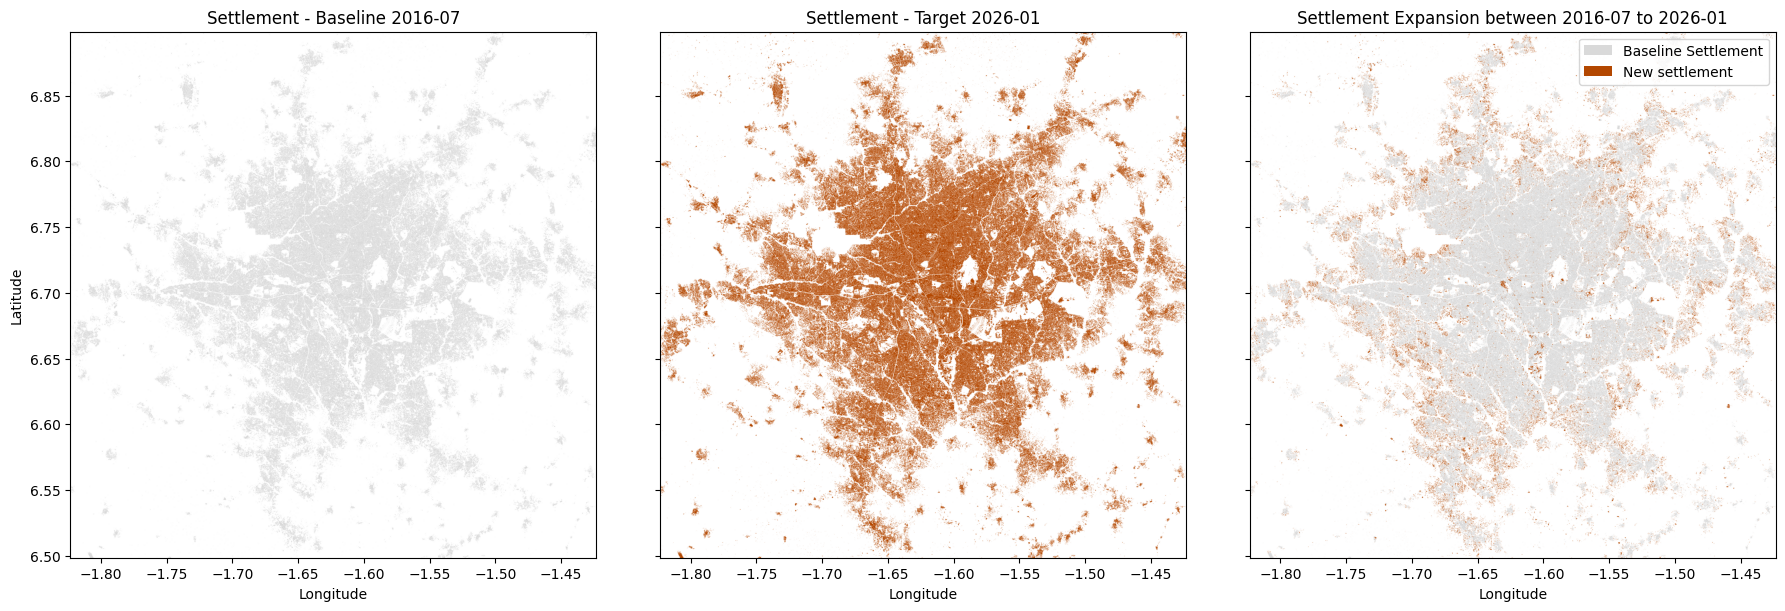

In [11]:
#Define the plot boundary
extent = [x.min(), x.max(), y.min(), y.max()]

#Define_colors
background_color = "white"
baseline_color = "#d9d9d9"
target_color = "#b34700"

# Discrete colour map
comparison_cmap = ListedColormap([background_color, baseline_color, target_color])
comparison_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], comparison_cmap.N)

# Plot settings
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, constrained_layout=True)

# 2017
axes[0].imshow(settlement_baseline, cmap=ListedColormap([background_color, baseline_color]), vmin=0, vmax=1, extent=extent, origin="upper")
axes[0].set_title(f"Settlement - Baseline {pd.Timestamp(baseline).strftime("%Y-%m")}")

# 2024
axes[1].imshow(settlement_target, cmap=ListedColormap([background_color, target_color]), vmin=0, vmax=1, extent=extent, origin="upper")
axes[1].set_title(f"Settlement - Target {pd.Timestamp(target).strftime("%Y-%m")}")

# Comparison
axes[2].imshow(comparison, cmap=comparison_cmap, norm=comparison_norm,  extent=extent,  origin="upper")
axes[2].set_title(f"Settlement Expansion between {pd.Timestamp(baseline).strftime("%Y-%m")} to {pd.Timestamp(target).strftime("%Y-%m")}")

# Legend
axes[2].legend(handles=[Patch(facecolor=baseline_color,  label="Baseline Settlement"),
        Patch(facecolor=target_color, label="New settlement")], loc="upper right")

# Define the axis name
axes[0].set_ylabel("Latitude")
for ax in axes:
    ax.set_xlabel("Longitude")

# Save image
plt.savefig('map_comparison_wsf.png', dpi=300)

# Plot image
plt.show()

### Plot settlement growth through time

This figure shows how the total cumulative settlement area changes over time and how much new settlement area is added during each WSF epoch.

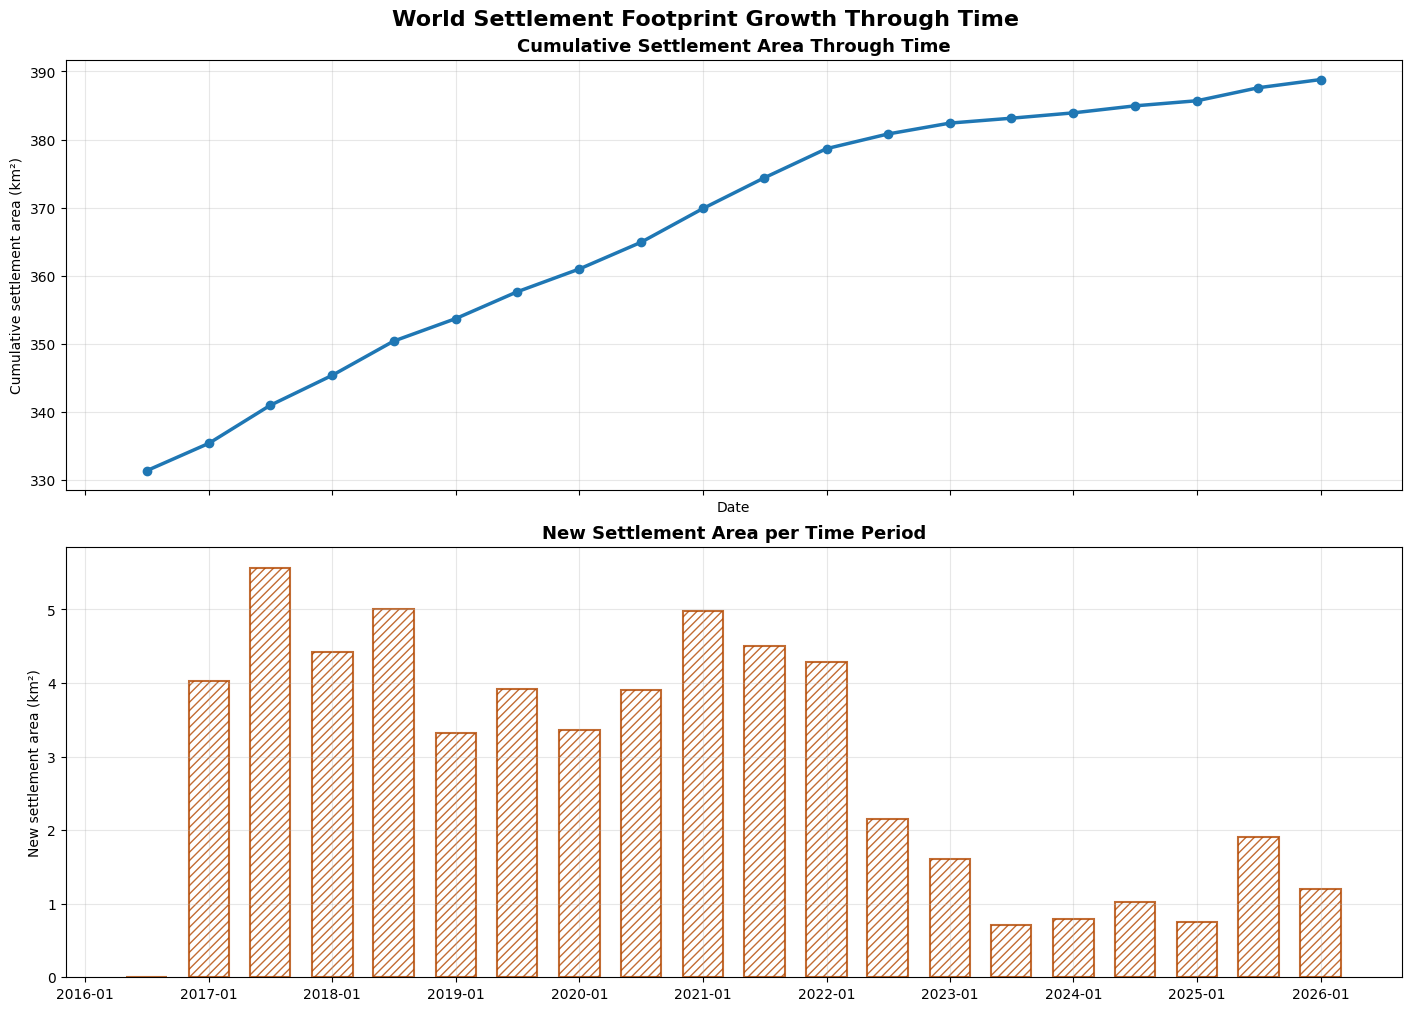

In [12]:
#Set plot proeprties
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

# Top: Cumulative settlement
ax1.plot(df["date"], df["cumulative_settlement_area_km2"], color="tab:blue", marker="o", linewidth=2.5, markersize=6)
ax1.set_title("Cumulative Settlement Area Through Time", fontsize=13, fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative settlement area (km²)")
ax1.grid(alpha=0.3)

# Bottom: New settlement per epoch
ax2.bar(df["date"], df["new_settlement_area_km2_per_period"],  width=120,color="tab:orange",alpha=0.8, hatch="////", linewidth=1.5, facecolor="white", edgecolor="#b34700",)
ax2.set_title("New Settlement Area per Time Period", fontsize=13, fontweight="bold")
ax2.set_ylabel("New settlement area (km²)")
ax2.grid(alpha=0.3)

# Date formatting
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("World Settlement Footprint Growth Through Time", fontsize=16, fontweight="bold")

# Save image
plt.savefig('graph_world_settlement_footprint.png', dpi=300)

# Show plot
plt.show()

### Conclusion

The World Settlement Footprint offers a knowledge base that can help researchers, governmental organizations, and other stakeholders, such as urban planners, better understand how urbanization is happening and, concurrently, put in place sustainable urban development strategies for informed policy decisions at local and national levels.


**Note**

To run for different area go to cell **Analysis parameters**, change the **lat** and **lon** values in the **define_area_function**.

---

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:**

In [13]:
print(datacube.__version__)

1.9.13


**Last tested:**

In [14]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-09-24'